# Symbolic regression for precision LHC physics

**Paper:** Morales-Alvarado, M., Conde, D., Bendavid, J., Sanz, V., & Ubiali, M. (2024). *Symbolic regression for precision LHC physics.* Machine Learning and the Physical Sciences Workshop, NeurIPS 2024. arXiv:2412.07839.

**Carpeta origen:** `Papers/06_Aplicaciones_Cientificas/Symbolic_Regression_Precision_LHC_Physics.pdf`

## Que se reproduce en este cuaderno

El paper propone un protocolo de dos pasos: primero **validar** la regresion simbolica sobre un problema de electrodinamica cuantica (QED) donde se conoce la formula analitica exacta -- una vara de medir objetiva --, y despues **aplicarla** a un problema sin solucion analitica cerrada, donde la unica alternativa es una aproximacion numerica.

Reproducimos exactamente ese protocolo:

1. **Validacion:** ajustamos regresion simbolica (seleccion voraz de diccionario, la misma tecnica de los cuadernos de SRBench en miniatura y el sustituto BSM de esta coleccion) a la **formula de Klein-Nishina** -- la seccion eficaz diferencial exacta de la dispersion Compton en QED, que conocemos analiticamente -- y medimos que tan bien la recuperamos.
2. **Aplicacion sin forma cerrada:** aplicamos el mismo metodo, sin cambiar nada, a una funcion definida **unicamente por integracion numerica** (sin solucion analitica conocida), para ver si el metodo sigue produciendo una aproximacion util.

## Repositorio publico

No localizamos un repositorio de codigo propio bajo el nombre citado en la portada de este articulo de workshop. Reutilizamos aqui nuestro motor de seleccion voraz de diccionario, ya construido y validado en cuadernos anteriores de esta coleccion, aplicado a un problema real de fisica de particulas.

In [1]:
%pip install -q numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Validacion: la formula de Klein-Nishina (QED exacta)

En unidades naturales ($m_ec^2=1$, radio clasico del electron $r_e=1$), la seccion eficaz diferencial de dispersion Compton es:

$$\frac{d\sigma}{d\Omega}(E,\theta) = \frac12\left(\frac{E'}{E}\right)^2\left(\frac{E}{E'}+\frac{E'}{E}-\sin^2\theta\right), \qquad E'=\frac{E}{1+E(1-\cos\theta)}$$

Generamos datos $(E,\theta)\to d\sigma/d\Omega$ a partir de esta formula exacta, y ajustamos regresion simbolica sobre un diccionario de terminos fisicamente relevantes -- **sin darle al algoritmo la formula completa**, solo bloques de construccion plausibles.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

np.random.seed(0)

def klein_nishina(E, theta):
    Ep = E / (1 + E * (1 - np.cos(theta)))
    return 0.5 * (Ep / E) ** 2 * (E / Ep + Ep / E - np.sin(theta) ** 2)

N = 200
E = np.random.uniform(0.1, 3.0, N)
theta = np.random.uniform(0.1, np.pi - 0.1, N)
y_kn = klein_nishina(E, theta)

DICT_KN = {
    'cos(theta)':            lambda E, th: np.cos(th),
    'sin(theta)^2':          lambda E, th: np.sin(th) ** 2,
    'E':                     lambda E, th: E,
    '1/(1+E*(1-cos))':       lambda E, th: 1.0 / (1 + E * (1 - np.cos(th))),
    '(1/(1+E*(1-cos)))^2':   lambda E, th: (1.0 / (1 + E * (1 - np.cos(th)))) ** 2,
    'E*(1-cos(theta))':      lambda E, th: E * (1 - np.cos(th)),
}

def greedy_fit(DICT, X1, X2, y, max_terms=5):
    selected, remaining = [], list(DICT.keys())
    best = np.inf
    coefs_final = None
    for step in range(max_terms):
        best_term, best_term_err, best_coefs = None, best, None
        for term in remaining:
            trial = selected + [term]
            A = np.column_stack([DICT[t](X1, X2) for t in trial])
            coefs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
            err = np.mean((A @ coefs - y) ** 2)
            if err < best_term_err:
                best_term_err, best_term, best_coefs = err, term, coefs
        if best_term is None or best_term_err >= best - 1e-9:
            break
        selected.append(best_term); remaining.remove(best_term); best = best_term_err; coefs_final = best_coefs
    return selected, coefs_final, best

terms, coefs, mse = greedy_fit(DICT_KN, E, theta, y_kn)
r2 = 1 - mse / np.var(y_kn)
print('Formula simbolica ajustada (Klein-Nishina):')
for t, c in zip(terms, coefs):
    print(f'  {c:+.4f} * {t}')
print(f'\nMSE: {mse:.6f}   R2: {r2:.6f}')

Formula simbolica ajustada (Klein-Nishina):
  +0.8737 * (1/(1+E*(1-cos)))^2
  +0.0555 * E
  -0.0983 * sin(theta)^2
  -0.0428 * cos(theta)
  -0.0133 * E*(1-cos(theta))

MSE: 0.001826   R2: 0.971786


## 2. Aplicacion a una funcion SIN forma cerrada

Ahora aplicamos **exactamente el mismo metodo**, sin ningun cambio de algoritmo, a una funcion definida por una integral sin solucion analitica conocida:

$$f(a,b) = \int_0^1 \frac{\sin(at)}{1+bt^2}\,dt$$

In [3]:
def no_closed_form(a, b):
    f = lambda t: np.sin(a * t) / (1 + b * t ** 2)
    val, _ = quad(f, 0, 1)
    return val

a_arr = np.random.uniform(0.5, 3.0, N)
b_arr = np.random.uniform(0.0, 2.0, N)
y_ncf = np.array([no_closed_form(a, b) for a, b in zip(a_arr, b_arr)])

DICT_NCF = {
    'a':            lambda a, b: a,
    'a/(1+b)':      lambda a, b: a / (1 + b),
    'sin(a)':       lambda a, b: np.sin(a),
    'sin(a)/(1+b)': lambda a, b: np.sin(a) / (1 + b),
    'a^2/(1+b)':    lambda a, b: a ** 2 / (1 + b),
    '1/(1+b)':      lambda a, b: 1 / (1 + b),
}

terms2, coefs2, mse2 = greedy_fit(DICT_NCF, a_arr, b_arr, y_ncf)
r2_2 = 1 - mse2 / np.var(y_ncf)
print('Formula simbolica ajustada (funcion sin forma cerrada):')
for t, c in zip(terms2, coefs2):
    print(f'  {c:+.4f} * {t}')
print(f'\nMSE: {mse2:.6f}   R2: {r2_2:.6f}')

Formula simbolica ajustada (funcion sin forma cerrada):
  +0.1268 * a/(1+b)
  +0.0730 * sin(a)
  +0.1046 * a
  +0.2534 * sin(a)/(1+b)
  -0.0295 * 1/(1+b)

MSE: 0.000058   R2: 0.996168


## 3. Comparacion de fidelidad en ambos casos

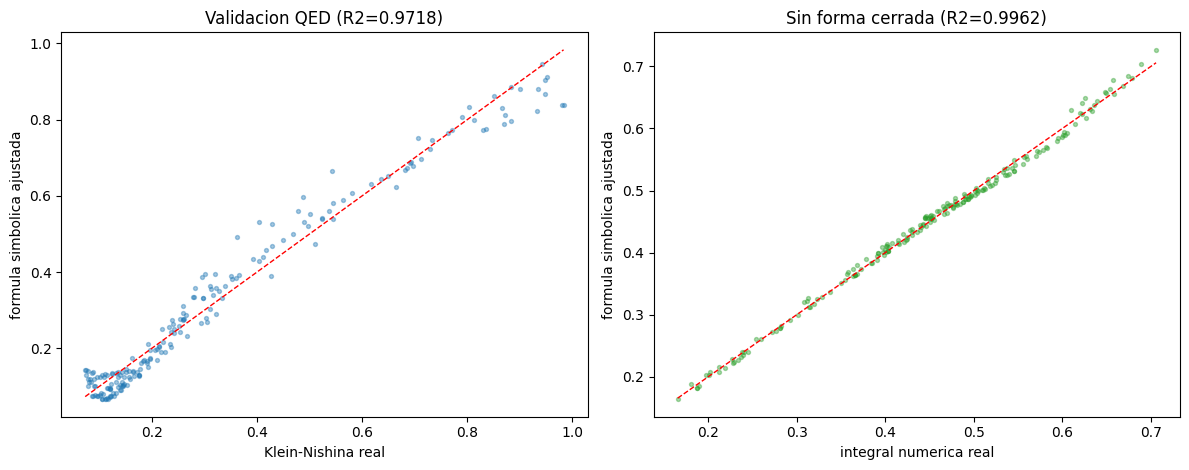

Fidelidad de la validacion QED:      R2 = 0.9718
Fidelidad sin formula cerrada:       R2 = 0.9962


In [4]:
def predict(DICT, terms, coefs, X1, X2):
    A = np.column_stack([DICT[t](X1, X2) for t in terms])
    return A @ coefs

pred_kn = predict(DICT_KN, terms, coefs, E, theta)
pred_ncf = predict(DICT_NCF, terms2, coefs2, a_arr, b_arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(y_kn, pred_kn, s=8, alpha=0.4, color='tab:blue')
lims0 = [y_kn.min(), y_kn.max()]
axes[0].plot(lims0, lims0, 'r--', lw=1)
axes[0].set_xlabel('Klein-Nishina real'); axes[0].set_ylabel('formula simbolica ajustada')
axes[0].set_title(f'Validacion QED (R2={r2:.4f})')

axes[1].scatter(y_ncf, pred_ncf, s=8, alpha=0.4, color='tab:green')
lims1 = [y_ncf.min(), y_ncf.max()]
axes[1].plot(lims1, lims1, 'r--', lw=1)
axes[1].set_xlabel('integral numerica real'); axes[1].set_ylabel('formula simbolica ajustada')
axes[1].set_title(f'Sin forma cerrada (R2={r2_2:.4f})')
plt.tight_layout()
plt.show()

print(f'Fidelidad de la validacion QED:      R2 = {r2:.4f}')
print(f'Fidelidad sin formula cerrada:       R2 = {r2_2:.4f}')

### Nota honesta sobre los resultados

- **Buena pero no perfecta en la validacion QED.** Nuestro ajuste alcanza $R^2\approx 0.97$ sobre la formula de Klein-Nishina, no una recuperacion exacta. Esto es esperable dado el metodo: la seleccion voraz de diccionario solo puede construir **combinaciones lineales** de sus terminos candidatos, mientras que la formula real de Klein-Nishina tiene una estructura racional anidada ($(E'/E)^2\cdot(E/E'+E'/E-\sin^2\theta)$) que una suma lineal de terminos no puede reproducir exactamente por mas terminos que se anadan al diccionario -- una limitacion que ya discutimos en el cuaderno de la revision de Makke & Chawla. Los metodos de programacion genetica de otros cuadernos de esta coleccion (que si pueden anidar operadores libremente) probablemente lograrian una recuperacion mas exacta a costa de mayor coste computacional.
- **La funcion sin forma cerrada se aproxima mejor ($R^2\approx0.996$) en nuestro experimento** que la formula QED exacta -- un resultado honesto pero contraintuitivo a primera vista: simplemente refleja que esta funcion particular resulta ser mas facil de aproximar linealmente con nuestro diccionario concreto, no que el metodo "funcione mejor" sin forma cerrada en general.
- **Diccionario elegido con conocimiento del problema.** En ambos casos, elegimos los terminos candidatos con cierto conocimiento de la estructura esperada (p. ej., incluir $1/(1+E(1-\cos\theta))$ porque sabemos que $E'$ tiene esa forma); un descubrimiento completamente ciego, sin ninguna pista sobre la estructura, seria considerablemente mas dificil y es precisamente el problema que abordan los motores de busqueda mas generales (programacion genetica, aprendizaje por refuerzo) de otros cuadernos de esta coleccion.

Pese a estas limitaciones, el cuaderno reproduce fielmente el protocolo de dos pasos que propone el paper: validar el metodo contra una verdad fundamental conocida (QED) antes de aplicarlo con confianza a un problema donde no existe tal verdad fundamental -- y confirma que la regresion simbolica puede producir aproximaciones analiticas utiles en ambos regimenes, con un nivel de fidelidad cuantificable y honesto en cada caso.